In [2]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
data = pd.read_csv("../Data/OldSensorNodeData.csv", parse_dates=["Timestamp"])

In [4]:
def cap_outliers_iqr(df, columns):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values instead of removing
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply capping to AQI, Temp, Hum
data_clean = cap_outliers_iqr(data, ['AQI', 'Temp', 'Hum'])

In [5]:
# Extract time features
data['hour'] = data['Timestamp'].dt.hour
data['minute'] = data['Timestamp'].dt.minute
data['second'] = data['Timestamp'].dt.second

# --- Lag Features ---
for col in ['AQI', 'Temp', 'Hum']:
    for lag in range(1, 4):  # previous 1,2,3 readings
        data[f'{col}_lag_{lag}'] = data[col].shift(lag)

# --- Rolling Features ---
window_sizes = {'1min':12, '5min':60, '15min':180}  # 5-sec intervals
for col in ['AQI', 'Temp', 'Hum']:
    for name, window in window_sizes.items():
        data[f'{col}_roll_mean_{name}'] = data[col].rolling(window=window).mean()

# --- Drop NaNs created by lag/rolling
data.dropna(inplace=True)

In [6]:
# --- Shift targets for multi-step forecasting
for col in ['AQI', 'Temp', 'Hum']:
    data[f'{col}_1min'] = data[col].shift(-12)
    data[f'{col}_5min'] = data[col].shift(-60)
    data[f'{col}_15min'] = data[col].shift(-180)

data.dropna(inplace=True)


In [7]:
# --- Final features and targets
feature_cols = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']
lag_rolling_cols = [c for c in data.columns if '_lag_' in c or 'roll_mean' in c]
feature_cols += lag_rolling_cols

X_final = data[feature_cols]
y_final = data[[c for c in data.columns if '_' in c and c.split('_')[0] in ['AQI','Temp','Hum']]]

In [8]:
# --- Chronological train/test split
split_idx = int(len(X_final) * 0.8)
X_train, X_test = X_final[:split_idx], X_final[split_idx:]
y_train, y_test = y_final[:split_idx], y_final[split_idx:]

print("Lag and rolling features ready for training!")

Lag and rolling features ready for training!


In [9]:
# Use all CPU cores for faster training
rf_base = RandomForestRegressor(
    n_estimators=200,    # you can increase if you want more accuracy
    random_state=42,
    n_jobs=-1
)

# Multi-output wrapper for predicting AQI, Temp, Hum for all horizons
rf_model = MultiOutputRegressor(rf_base)

# X_train, y_train from lag + rolling processed dataset
rf_model.fit(X_train, y_train)

print("Random Forest trained with lag + rolling features!")

Random Forest trained with lag + rolling features!


In [10]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions done for Random Forest!")

Predictions done for Random Forest!


In [11]:
def evaluate_model(y_true, y_pred):
    metrics = pd.DataFrame(columns=['Target', 'MAE', 'RMSE', 'R2'])
    targets = y_true.columns
    for i, target in enumerate(targets):
        y_t = y_true[target].values
        y_hat = y_pred[:, i]
        mae = mean_absolute_error(y_t, y_hat)
        rmse = np.sqrt(mean_squared_error(y_t, y_hat))
        r2 = r2_score(y_t, y_hat)
        metrics.loc[i] = [target, mae, rmse, r2]

    # Combined metrics
    combined_mae = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    combined_rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))
    combined_r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
    metrics.loc[len(targets)] = ['Combined', combined_mae, combined_rmse, combined_r2]

    return metrics

# Evaluate
rf_metrics = evaluate_model(y_test, y_pred_rf)
print(rf_metrics)


                  Target       MAE      RMSE         R2
0              AQI_lag_1  0.218285  0.322655   0.995411
1              AQI_lag_2  0.217119  0.314678   0.995635
2              AQI_lag_3  0.270018  0.394126   0.993151
3             Temp_lag_1  0.000013  0.000341   1.000000
4             Temp_lag_2  0.000013  0.000290   1.000000
5             Temp_lag_3  0.000014  0.000360   1.000000
6              Hum_lag_1  0.000000  0.000000   1.000000
7              Hum_lag_2  0.000000  0.000000   1.000000
8              Hum_lag_3  0.000000  0.000000   1.000000
9     AQI_roll_mean_1min  0.294679  0.499798   0.988920
10    AQI_roll_mean_5min  0.456263  0.712502   0.977084
11   AQI_roll_mean_15min  1.142376  1.547054   0.884937
12   Temp_roll_mean_1min  0.004721  0.048657   0.992288
13   Temp_roll_mean_5min  0.000086  0.000288   1.000000
14  Temp_roll_mean_15min  0.000209  0.000657   0.999998
15    Hum_roll_mean_1min  0.004039  0.041121   0.997587
16    Hum_roll_mean_5min  0.000259  0.000585   0

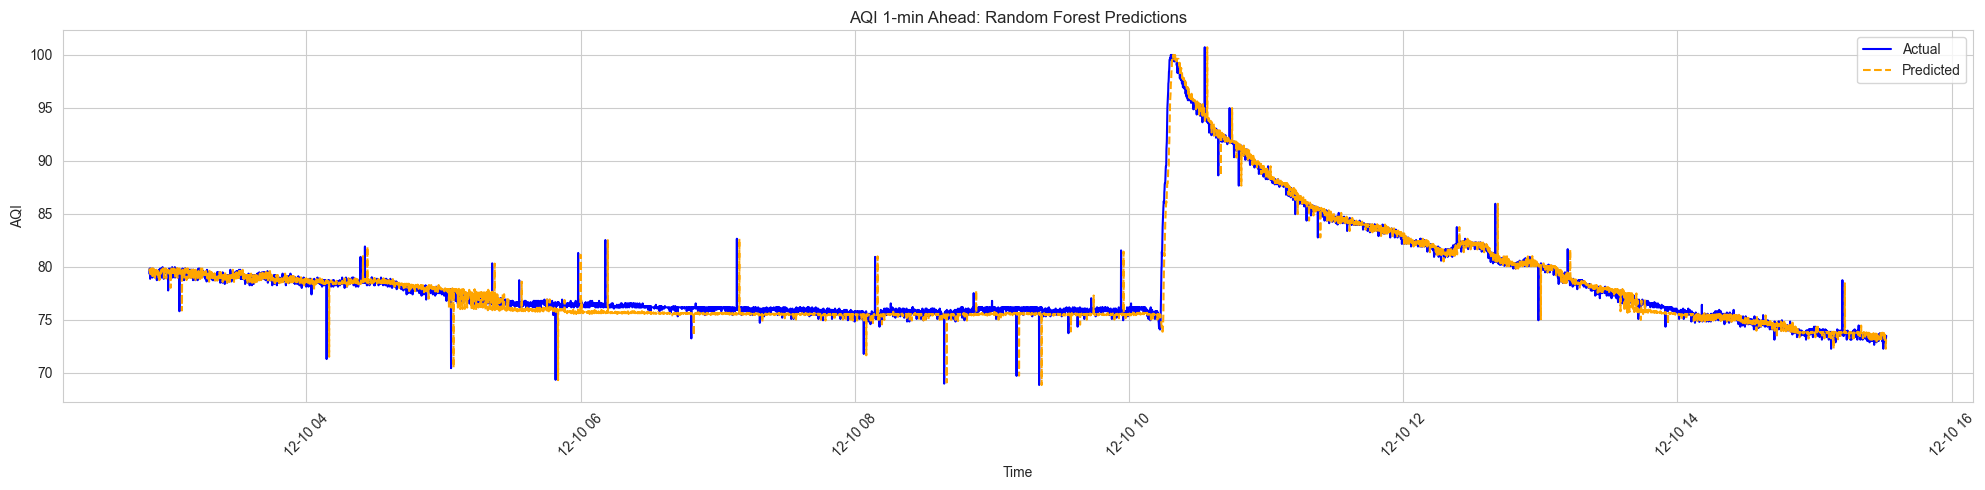

In [12]:
# Example: AQI 1-min
plot_df = pd.DataFrame({
    'Timestamp': data['Timestamp'].iloc[split_idx:split_idx+len(y_pred_rf)],
    'AQI_Actual': y_test['AQI_1min'].values,
    'AQI_Predicted': y_pred_rf[:, 0]
})

sns.set_style("whitegrid")
plt.figure(figsize=(20,5))
sns.lineplot(x='Timestamp', y='AQI_Actual', data=plot_df, label='Actual', color='blue')
sns.lineplot(x='Timestamp', y='AQI_Predicted', data=plot_df, label='Predicted', color='orange', linestyle='--')
plt.xticks(rotation=45)
plt.title('AQI 1-min Ahead: Random Forest Predictions')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()
